In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
from datetime import datetime


import sys
import os

In [58]:
# MAGIA (não mexer mt pfv)
def show_args(func):
    def wrapper(*args, **kwargs):
        arg_list = []

        # Prepare argument list
        for name, value in zip(func.__code__.co_varnames, args):
            if isinstance(value, pd.DataFrame):
                arg_list.append(f"{name}: DataFrame ({value.shape})")
            else:
                arg_list.append(f"{name}: {value}")
        for k, v in kwargs.items():
            if isinstance(v, pd.DataFrame):
                arg_list.append(f"{k}: DataFrame ({v.shape})")
            else:
                arg_list.append(f"{k}: {v}")

        print(f"Executando <{func.__name__}>\n({'\\n'.join(arg_list)})")

        # Measure execution time
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()

        print(f"Tempo de execução: {end - start:.6f} segundos\n")
        return result
    return wrapper

In [59]:
from pathlib import Path
@show_args
def csvs_to_parquet(folder_path):
    folder = Path(folder_path)
    for csv_file in folder.glob("*.csv"):
        df = pd.read_csv(csv_file)
        df.to_parquet(csv_file.with_suffix(".parquet"), index=False)


In [60]:
#csvs_to_parquet("../data/data/refined/csvs")

In [61]:
departments_raw = pd.read_parquet('../data/data/refined/departments.parquet').rename(columns={
    'dptid': 'dpt_id',
    'organization': 'dpt_name'
})

authors_institutions_raw = pd.read_parquet('../data/data/refined/authors_institution.parquet').rename(columns={
    'affiliation id': 'aff_id',
    'auid': 'author_id',
    'dptid': 'dpt_id'
})

authors_raw = pd.read_parquet('../data/data/refined/author.parquet').rename(columns={
    'auid': 'author_id',
    'given name': 'name',
    'surname': 'surname',
    'indexed name': 'indexed_name',
})

articles_authors_raw = pd.read_parquet('../data/data/refined/articles_author.parquet').rename(columns={
    'eid': 'article_id',
    'auid': 'author_id',
    'creator': 'main_writer'
})

articles_raw = pd.read_parquet('../data/data/refined/article.parquet').rename(columns={
    'eid': 'article_id',
    'title': 'title',
    'published date': 'published_date',
    'cited by count': 'citations'
})

articles_subject_areas_raw = pd.read_parquet('../data/data/refined/article_subject_areas.parquet').rename(columns={
    'eid': 'article_id',
    'subject area code': 'subj_id'
})

subject_areas_raw = pd.read_parquet('../data/data/refined/subject_area.parquet')

In [62]:
articles_subject_areas_raw.head()

,article_id,subj_id
0,2-s2.0-84951935294,2701
1,2-s2.0-84951935294,2916
2,2-s2.0-84954443335,3612
3,2-s2.0-84948760347,3005
4,2-s2.0-84948760347,2307


In [63]:
article__article_authors = pd.merge(articles_raw, articles_authors_raw, on='article_id', how='inner')
article__article_authors.head()

,article_id,title,published_date,citations,author_id,main_writer
0,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,56862304200,True
1,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,16241649700,False
2,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,54400149800,False
3,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,6506627898,False
4,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,36038154600,False


In [64]:
articles_subject_areas__subject_areas = pd.merge(articles_subject_areas_raw, subject_areas_raw, on='subj_id', how='inner')
articles_subject_areas__subject_areas.head()

,article_id,subj_id,area,abv
0,2-s2.0-84951935294,2701,Medicine (miscellaneous),MEDI
1,2-s2.0-84951935294,2916,Nutrition and Dietetics,NURS
2,2-s2.0-84954443335,3612,"Physical Therapy, Sports Therapy and Rehabilit...",HEAL
3,2-s2.0-84948760347,3005,Toxicology,PHAR
4,2-s2.0-84948760347,2307,"Health, Toxicology and Mutagenesis",ENVI


In [65]:
author__authors_institutions = pd.merge(authors_raw, authors_institutions_raw, on='author_id', how='inner')
author__authors_institutions.head()

,author_id,name,surname,indexed_name,aff_id,dpt_id
0,56862304200,Giliane,Belarmino,Belarmino G.,60008088,113102196.0
1,56862304200,Giliane,Belarmino,Belarmino G.,60008088,115721009.0
2,56862304200,Giliane,Belarmino,Belarmino G.,131890482,131890720.0
3,56862304200,Giliane,Belarmino,Belarmino G.,60008088,108193373.0
4,56862304200,Giliane,Belarmino,Belarmino G.,60008088,113563057.0


In [66]:
author__departments = pd.merge(author__authors_institutions, departments_raw, on='dpt_id', how='inner')
author__departments.head()

,author_id,name,surname,indexed_name,aff_id,dpt_id,dpt_name
0,56862304200,Giliane,Belarmino,Belarmino G.,60008088,113102196.0,"Department of Gastroenterology, Surgical Divis..."
1,56862304200,Giliane,Belarmino,Belarmino G.,60008088,115721009.0,Nutrition Laboratory and Metabolic Surgery of ...
2,56862304200,Giliane,Belarmino,Belarmino G.,131890482,131890720.0,Nutrition Laboratory and Metabolic Surgery of ...
3,56862304200,Giliane,Belarmino,Belarmino G.,60008088,108193373.0,"FMUSP - Department of Gastroenterology, Digest..."
4,56862304200,Giliane,Belarmino,Belarmino G.,60008088,113563057.0,"University of São Paulo, Medical School, Depar..."


In [67]:
main = pd.merge(article__article_authors, author__departments, on='author_id', how='inner')
main = pd.merge(main, articles_subject_areas__subject_areas, on='article_id', how='inner')
main.head()

,article_id,title,published_date,citations,author_id,main_writer,name,surname,indexed_name,aff_id,dpt_id,dpt_name,subj_id,area,abv
0,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,56862304200,True,Giliane,Belarmino,Belarmino G.,60008088,113102196.0,"Department of Gastroenterology, Surgical Divis...",2701,Medicine (miscellaneous),MEDI
1,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,56862304200,True,Giliane,Belarmino,Belarmino G.,60008088,113102196.0,"Department of Gastroenterology, Surgical Divis...",2916,Nutrition and Dietetics,NURS
2,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,56862304200,True,Giliane,Belarmino,Belarmino G.,60008088,115721009.0,Nutrition Laboratory and Metabolic Surgery of ...,2701,Medicine (miscellaneous),MEDI
3,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,56862304200,True,Giliane,Belarmino,Belarmino G.,60008088,115721009.0,Nutrition Laboratory and Metabolic Surgery of ...,2916,Nutrition and Dietetics,NURS
4,2-s2.0-84951935294,Body adiposity index performance in estimating...,2015-12-30,18.0,56862304200,True,Giliane,Belarmino,Belarmino G.,131890482,131890720.0,Nutrition Laboratory and Metabolic Surgery of ...,2701,Medicine (miscellaneous),MEDI


In [68]:
main.shape

(80297978, 15)

In [69]:
teste = main.head(1000)
teste.to_csv('teste.csv')

### Frquência de áreas

#### Grouped -> Exploded -> Frequency

In [70]:
# Group by title and collect all unique areas into a list
grouped = main.groupby('title')['area'].unique().reset_index()

# Explode the list so each area gets its own row
exploded = grouped.explode('area').reset_index(drop=True)

area_frequency = exploded['area'].value_counts().sort_values(ascending=False)

area_frequency.to_csv('area_frequency.csv', header=['frequency'])

C:\Users\aline\AppData\Local\Temp\ipykernel_26336\1199070264.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


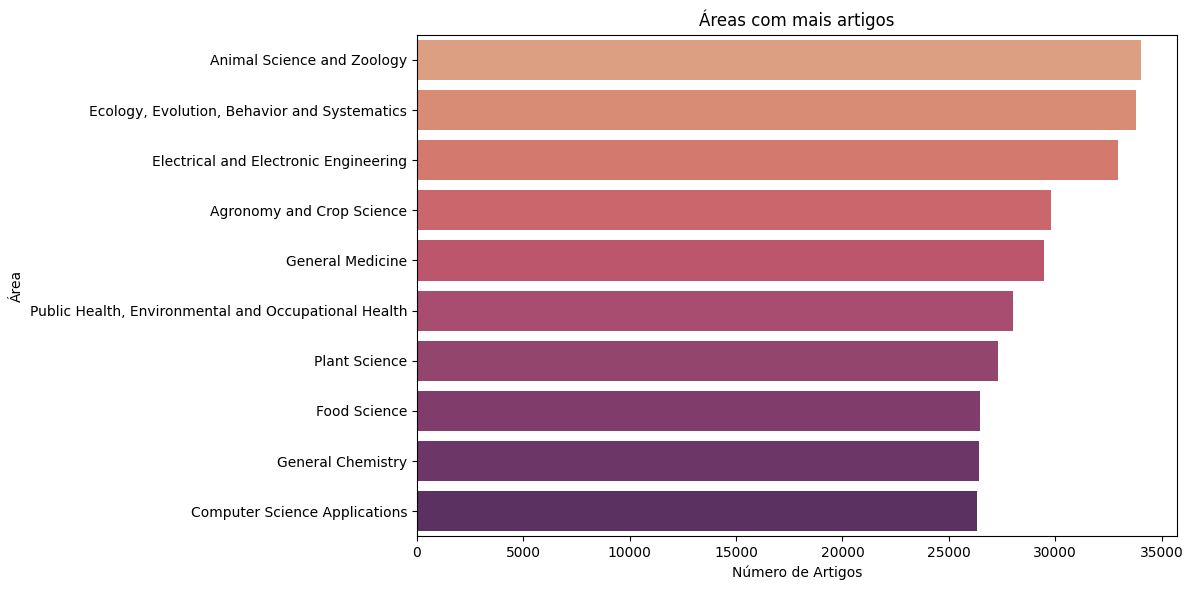

In [71]:
# Take top 10 areas and convert to DataFrame
top_areas = area_frequency.head(10).reset_index()
top_areas.columns = ['area', 'frequency']  # rename columns

plt.figure(figsize=(12, 6))

palette = sns.color_palette('flare', 10)

sns.barplot(
    x='frequency', 
    y='area',
    data=top_areas,
    palette=palette
)

plt.title('Áreas com mais artigos')
plt.xlabel('Número de Artigos')
plt.ylabel('Área')
plt.tight_layout()
plt.show()

### Frequência de Departamentos

#### grouped_dept -> exploded_dept -> dept_frequency

In [72]:
# Group by title and collect all unique department names into a list
grouped_dept = main.groupby('title')['dpt_name'].unique().reset_index()

# Explode the list so each department gets its own row
exploded_dept = grouped_dept.explode('dpt_name').reset_index(drop=True)

# Count the frequency of each department
dept_frequency = exploded_dept['dpt_name'].value_counts().sort_values(ascending=False)

# Save to CSV
dept_frequency.to_csv('department_frequency.csv', header=['frequency'])

C:\Users\aline\AppData\Local\Temp\ipykernel_26336\3044416271.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


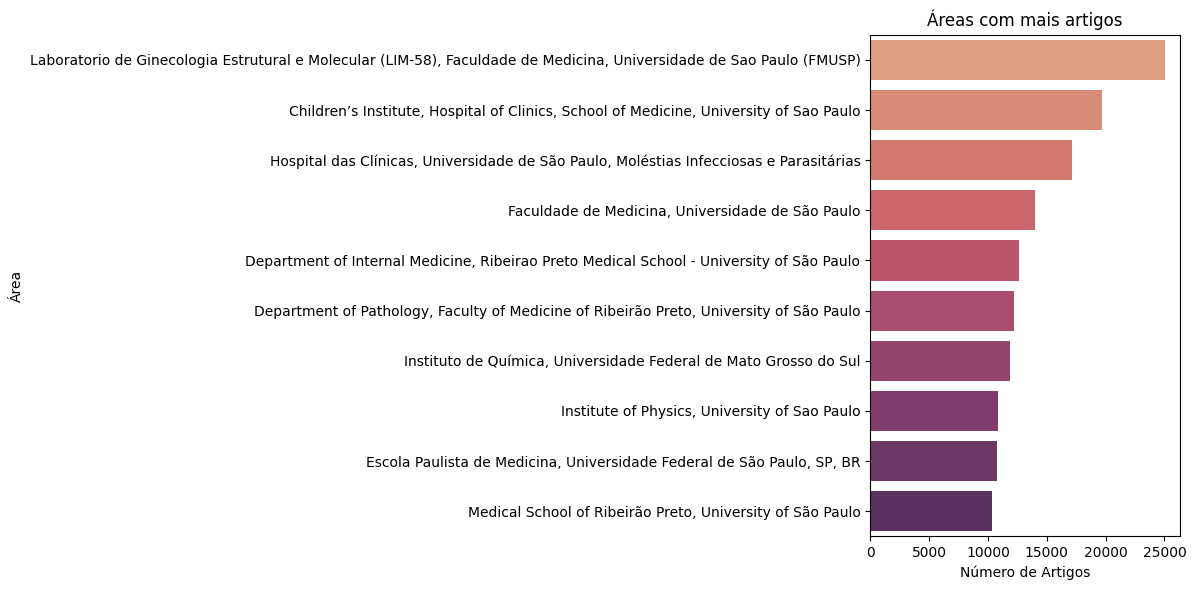

In [73]:
# Take top 10 areas and convert to DataFrame
top_depts = dept_frequency.head(10).reset_index()
top_depts.columns = ['department', 'frequency']  # rename columns

plt.figure(figsize=(12, 6))

sns.barplot(
    x='frequency', 
    y='department',
    data=top_depts,
    palette=palette
)

plt.title('Áreas com mais artigos')
plt.xlabel('Número de Artigos')
plt.ylabel('Área')
plt.tight_layout()
plt.show()

### Autores com mais publicações (ENVIESADO)

In [74]:
# Remove duplicate article-author pairs
unique_author_articles = main[['author_id', 'name', 'surname', 'title']].drop_duplicates()

# Count number of articles per author
author_counts = unique_author_articles.groupby(['author_id', 'name', 'surname']).size().reset_index(name='num_articles')

# Sort descending
top_authors = author_counts.sort_values(by='num_articles', ascending=False)

# Optional: take top 10 authors
top_authors_10 = top_authors.head(10)

# Save to CSV
top_authors.to_csv('authors_most_articles.csv', index=False)

print(top_authors_10)


           author_id               name   surname  num_articles
147853   15135600900                 F.    Fabbri          1719
245921   36721719900  Maria Lcia Zaidan     Dagli          1506
85488     7101661057              I. G.     Sipes          1436
586042   57203082737              T. W.   schultz          1436
69659     7005341126                 D.   Belsito          1436
68597     7005218440                 M.     Bruze          1436
91095     7102607785              A. D.     Fryer          1436
319988   55728695200                 An  Vorobyev          1425
1000540  59454508500              G. A.    Burton          1379
213144   35228083400              S. K.     Swain          1291


### Artigos Mais citados

#### unique_articles -> most cited -> top_citations

In [75]:
# Drop duplicates just in case an article appears multiple times with same citations
unique_articles = main[['title', 'citations']].drop_duplicates()

# Sort by citations (highest first)
most_cited = unique_articles.sort_values(by='citations', ascending=False)

# Save to CSV
most_cited.to_csv('articles_most_cited.csv', index=False)

C:\Users\aline\AppData\Local\Temp\ipykernel_26336\3794067492.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


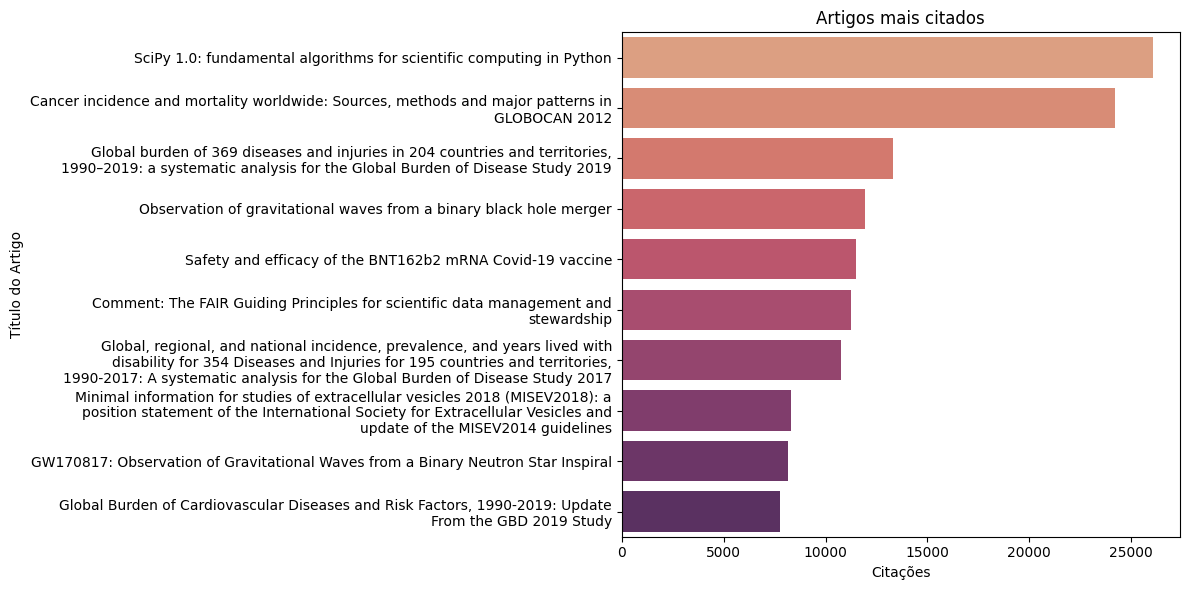

In [76]:
import textwrap

top_citations = most_cited.head(10).reset_index(drop=True)
top_citations.columns = ['title', 'citations']

top_citations['title_wrapped'] = top_citations['title'].apply(
    lambda x: '\n'.join(textwrap.wrap(x, width=80))
)


plt.figure(figsize=(12, 6))
sns.barplot(
    x='citations',
    y='title_wrapped',
    data=top_citations,
    palette=palette
)

plt.title('Artigos mais citados')
plt.xlabel('Citações')
plt.ylabel('Título do Artigo')
plt.tight_layout()
plt.show()


In [77]:
teste = main[main['title'] == 'SciPy 1.0: fundamental algorithms for scientific computing in Python']
teste.to_csv('teste.csv', index=False)